In [10]:
#NLP preprocessing TECHINQUE

import pandas as pd


textdata= pd.read_table('captions.txt')
textdata

,ROCO_00002,Computed tomography scan in axial view showing obliteration of the left maxillary sinus
0,ROCO_00003,Bacterial contamination occurred after comple...
1,ROCO_00004,The patient had residual paralysis of the han...
2,ROCO_00005,Panoramic radiograph after immediate loading.
3,ROCO_00007,Plain abdomen x-ray: Multiple air levels at t...
4,ROCO_00008,A 3-year-old child with visual difficulties. ...
...,...,...
65444,ROCO_81819,Initial CT abdomen with contrast showing a di...
65445,ROCO_81820,44-year-old male patient after surgical amput...
65446,ROCO_81821,Primary pulmonary tuberculosis in 18-year-old...
65447,ROCO_81822,"MRI brain with gadolinium, coronal view, show..."


In [12]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import download
import nltk


nltk.download('stopwords')  
nltk.download('punkt')      
nltk.download('wordnet')    
nltk.download('omw-1.4')    



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\styap\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\styap\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\styap\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\styap\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [8]:
from nltk.corpus import stopwords
print(stopwords.words('english')[:10])  # Displays the first 10 stopwords


['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're"]


In [30]:
# Tokenization
import nltk
from nltk.tokenize import word_tokenize

# Tokenize the captions
textdata['tokens'] = textdata['caption'].apply(word_tokenize)


print(textdata[['Image_ID', 'tokens']].head())


     Image_ID                                             tokens
0  ROCO_00002  [Computed, tomography, scan, in, axial, view, ...
1  ROCO_00003  [Bacterial, contamination, occurred, after, co...
2  ROCO_00004  [The, patient, had, residual, paralysis, of, t...
3  ROCO_00005  [Panoramic, radiograph, after, immediate, load...
4  ROCO_00007  [Plain, abdomen, x-ray, :, Multiple, air, leve...


In [32]:
# Lowercasing

textdata['tokens'] = textdata['tokens'].apply(lambda x: [word.lower() for word in x])

# Display the first few rows
print(textdata[['Image_ID', 'tokens']].head())


     Image_ID                                             tokens
0  ROCO_00002  [computed, tomography, scan, in, axial, view, ...
1  ROCO_00003  [bacterial, contamination, occurred, after, co...
2  ROCO_00004  [the, patient, had, residual, paralysis, of, t...
3  ROCO_00005  [panoramic, radiograph, after, immediate, load...
4  ROCO_00007  [plain, abdomen, x-ray, :, multiple, air, leve...


In [34]:

 # Removing Punctuation & Non-Alphanumeric Characters

# Remove punctuation
textdata['tokens'] = textdata['tokens'].apply(lambda x: [word for word in x if word.isalnum()])


print(textdata[['Image_ID', 'tokens']].head())


     Image_ID                                             tokens
0  ROCO_00002  [computed, tomography, scan, in, axial, view, ...
1  ROCO_00003  [bacterial, contamination, occurred, after, co...
2  ROCO_00004  [the, patient, had, residual, paralysis, of, t...
3  ROCO_00005  [panoramic, radiograph, after, immediate, load...
4  ROCO_00007  [plain, abdomen, multiple, air, levels, at, th...


In [36]:
 #Removing Stopwords
from nltk.corpus import stopwords


stop_words = set(stopwords.words('english'))

# Remove stopwords
textdata['tokens'] = textdata['tokens'].apply(lambda x: [word for word in x if word not in stop_words])


print(textdata[['Image_ID', 'tokens']].head())


     Image_ID                                             tokens
0  ROCO_00002  [computed, tomography, scan, axial, view, show...
1  ROCO_00003  [bacterial, contamination, occurred, completio...
2  ROCO_00004  [patient, residual, paralysis, hand, poliomyel...
3  ROCO_00005        [panoramic, radiograph, immediate, loading]
4  ROCO_00007  [plain, abdomen, multiple, air, levels, arrows...


In [41]:

# Stemming
from nltk.stem import PorterStemmer


stemmer = PorterStemmer()


textdata['tokens'] = textdata['tokens'].apply(lambda x: [stemmer.stem(word) for word in x])


print(textdata[['Image_ID', 'tokens']].head())


     Image_ID                                             tokens
0  ROCO_00002  [comput, tomographi, scan, axial, view, show, ...
1  ROCO_00003  [bacteri, contamin, occur, complet, root, cana...
2  ROCO_00004  [patient, residu, paralysi, hand, poliomyel, n...
3  ROCO_00005                [panoram, radiograph, immedi, load]
4  ROCO_00007  [plain, abdomen, multipl, air, level, arrow, r...


In [41]:

#Lemmatization 
from nltk.stem import WordNetLemmatizer




lemmatizer = WordNetLemmatizer()


textdata['tokens'] = textdata['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

print(textdata[['Image_ID', 'tokens']].head())


     Image_ID                                             tokens
0  ROCO_00002  [Computed, tomography, scan, in, axial, view, ...
1  ROCO_00003  [Bacterial, contamination, occurred, after, co...
2  ROCO_00004  [The, patient, had, residual, paralysis, of, t...
3  ROCO_00005  [Panoramic, radiograph, after, immediate, load...
4  ROCO_00007  [Plain, abdomen, x-ray, :, Multiple, air, leve...


In [40]:
# COMBINING ALL
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer



textdata = pd.read_table('captions.txt', header=None, names=['Image_ID', 'caption'])

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def tokenize(text):
    return word_tokenize(text)


def lowercase(text):
    return text.lower()


def remove_punctuation(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Function for stemming
def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

# Function for lemmatization (use either stemming or lemmatization)
def lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply tokenization
textdata['tokens'] = textdata['caption'].apply(tokenize)
print("Step 1: Tokenization")
print(textdata.head())

# Apply lowercasing
textdata['lowercased'] = textdata['caption'].apply(lowercase)
print("\nStep 2: Lowercasing")
print(textdata.head())

# Apply removing punctuation
textdata['cleaned'] = textdata['lowercased'].apply(remove_punctuation)
print("\nStep 3: Removing Punctuation & Non-Alphanumeric Characters")
print(textdata.head())

# Apply removing stopwords
textdata['stopwords_removed'] = textdata['tokens'].apply(remove_stopwords)
print("\nStep 4: Removing Stopwords")
print(textdata.head())

# Apply stemming
textdata['stemmed'] = textdata['stopwords_removed'].apply(stemming)
print("\nStep 5: Stemming")
print(textdata.head())





Step 1: Tokenization
     Image_ID                                            caption  \
0  ROCO_00002   Computed tomography scan in axial view showin...   
1  ROCO_00003   Bacterial contamination occurred after comple...   
2  ROCO_00004   The patient had residual paralysis of the han...   
3  ROCO_00005      Panoramic radiograph after immediate loading.   
4  ROCO_00007   Plain abdomen x-ray: Multiple air levels at t...   

                                              tokens  
0  [Computed, tomography, scan, in, axial, view, ...  
1  [Bacterial, contamination, occurred, after, co...  
2  [The, patient, had, residual, paralysis, of, t...  
3  [Panoramic, radiograph, after, immediate, load...  
4  [Plain, abdomen, x-ray, :, Multiple, air, leve...  

Step 2: Lowercasing
     Image_ID                                            caption  \
0  ROCO_00002   Computed tomography scan in axial view showin...   
1  ROCO_00003   Bacterial contamination occurred after comple...   
2  ROCO_00004  

In [38]:
# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()

# Define stopwords
stop_words = set(stopwords.words('english'))

# Preprocessing function
def preprocess_text(text):
    # Tokenization
    tokens = word_tokenize(text)
    
    # Lowercasing
    tokens = [word.lower() for word in tokens]
    
    # Remove punctuation
    tokens = [word for word in tokens if word not in string.punctuation]
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return tokens

# Apply preprocessing to captions
textdata['processed_caption'] = textdata['caption'].apply(preprocess_text)


print(textdata[['Image_ID', 'processed_caption']].head())


NameError: name 'stopwords' is not defined

In [42]:

# TF-IDF




from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
f
# Join the tokens back into a string for each caption
textdata['processed_caption_str'] = textdata['processed_caption'].apply(lambda x: ' '.join(x))


vectorizer = TfidfVectorizer(max_features=10)  # Limit the number of features to 10 for simplicity
X_tfidf = vectorizer.fit_transform(textdata['processed_caption_str'])

# Convert the TF-IDF matrix to a DataFrame and show the result
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
print(tfidf_df.head())


NameError: name 'f' is not defined

In [59]:
# Train a Word2Vec model using the processed tokens
word2vec_model = Word2Vec(textdata['processed_caption'], vector_size=100, window=5, min_count=1, workers=4)


word2vec_model.save("word2vec_model.model")

word_vector = word2vec_model.wv['patient'] 
print(word_vector)

similar_words = word2vec_model.wv.most_similar('patient', topn=5)
print(similar_words)


[-6.5985225e-02 -2.5557941e-01 -1.4815050e+00  2.1796284e+00
  1.0027895e+00 -6.1723971e-01 -4.9276969e-01  1.1725901e+00
 -7.4277353e-01 -1.1165396e+00 -9.9649185e-01  4.4923958e-01
  1.3246272e+00  8.5953009e-01  1.1000627e+00 -2.6195896e-01
  1.3901729e-03 -4.3574962e-01  3.2646984e-01 -7.7589744e-01
 -2.1678162e-01  3.2117647e-01 -2.2303939e+00 -9.2069161e-01
  1.2547754e+00 -9.6358791e-02 -1.8220458e+00  8.3609450e-01
 -1.2797662e+00  1.0278625e+00 -3.9079997e-01 -2.6451370e-01
 -9.6998900e-01 -6.3508868e-01 -9.8393285e-01  2.6094944e+00
 -1.1845025e+00  6.1774457e-01  1.0081038e+00 -2.8924486e-01
  1.5061463e-01 -6.7430001e-01  1.5488046e+00  1.0291593e+00
  7.9361522e-01  1.0394817e-01 -7.5990236e-01 -9.4558060e-01
  2.0169560e-02  7.5748968e-01  2.0875111e+00  6.0124153e-01
  9.2635965e-01  3.2762516e-01  1.1715155e+00  2.2599198e-01
  5.6375194e-01 -1.6883011e-01 -8.3205360e-01 -1.6938031e-01
 -6.4148718e-01  1.5177903e-01  3.0593971e-02 -9.1021580e-01
 -1.1074101e+00 -9.66304

In [ ]:
# VGG16 Feature Map Extraction


In [1]:
pip install tensorflow keras


Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os


In [ ]:
# Load the VGG16 model without the classification (fully connected) layers
base_model = VGG16(weights='imagenet', include_top=False)
model = Model(inputs=base_model.input, outputs=base_model.layers[-1].output)  # Output at the last convolutional layer


In [ ]:
# Path to the image
image_path = 'traindataimages/PMC1065094_cc2940-1.jpg' 

# Load the image and resize it to 224x224
image = load_img(image_path, target_size=(224, 224))

# Convert the image to a numpy array
image_array = img_to_array(image)

# Expand dimensions to match VGG16 input format and preprocess
image_array = np.expand_dims(image_array, axis=0)
image_array = preprocess_input(image_array)  # Preprocess for VGG16


In [14]:
# Generate feature maps
feature_maps = model.predict(image_array)
print("Shape of feature maps:", feature_maps.shape)  # Output dimensions


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Shape of feature maps: (1, 7, 7, 512)


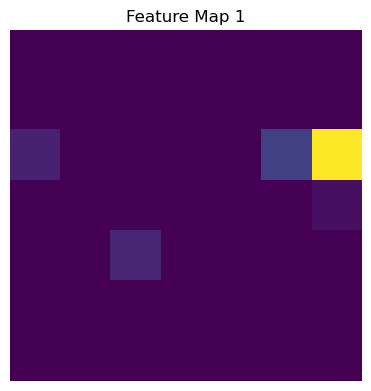

In [26]:
# Plot the first few feature maps (e.g., 16 maps)
plt.figure(figsize=(15, 15))
n_maps = 1 # Number of feature maps to display

for i in range(n_maps):
    plt.subplot(4, 4, i + 1)  # 4x4 grid
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f"Feature Map {i+1}")

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Feature map shape: (1, 7, 7, 512)


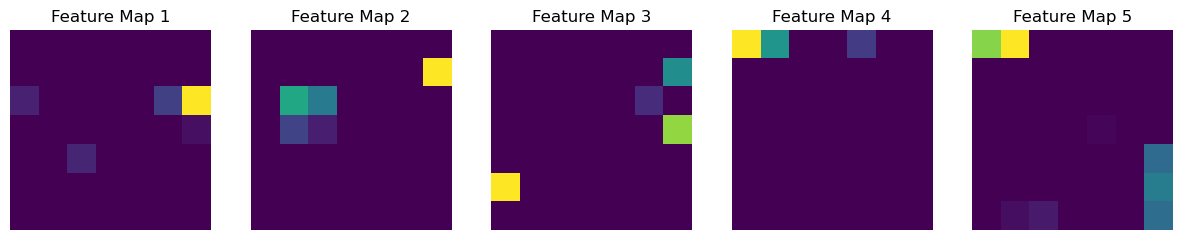

In [20]:
# Import necessary libraries
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt

# Path to the image
image_path = 'traindataimages/PMC1065094_cc2940-1.jpg'  # Replace with your image path

# Load the image and resize it to 224x224
image = load_img(image_path, target_size=(224, 224))

# Convert the image to a numpy array
image_array = img_to_array(image)

# Expand dimensions to match VGG16 input format
image_array = np.expand_dims(image_array, axis=0)

# Preprocess the image for VGG16
image_array = preprocess_input(image_array)

# Load VGG16 model pre-trained on ImageNet (include the top layer for classification)
model = VGG16(weights='imagenet', include_top=False)  # We exclude the top layer for feature extraction

# Get the feature map for the image (we use the model to predict the features)
feature_map = model.predict(image_array)

# The feature map shape
print(f"Feature map shape: {feature_map.shape}")

# Visualize the feature map - You can choose a particular layer from the model
# For this case, let's visualize the first few feature maps

# For simplicity, we'll visualize the first few filters of the first layer
fig, axes = plt.subplots(1, 5, figsize=(15, 15))

for i in range(5):  # Displaying first 5 feature maps
    ax = axes[i]
    ax.imshow(feature_map[0, :, :, i], cmap='viridis')
    ax.axis('off')
    ax.set_title(f"Feature Map {i + 1}")

plt.show()



In [28]:

# Artificial Neural Network (ANN)




# Import necessary libraries
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Path to the image
image_path = 'traindataimages/PMC1065094_cc2940-1.jpg'  # Replace with your image path

# Load the image and resize it to 224x224
image = load_img(image_path, target_size=(224, 224))

# Convert the image to a numpy array
image_array = img_to_array(image)

# Expand dimensions to match VGG16 input format
image_array = np.expand_dims(image_array, axis=0)

# Preprocess the image for VGG16
image_array = preprocess_input(image_array)

# Load VGG16 model pre-trained on ImageNet (exclude top layer for feature extraction)
model = VGG16(weights='imagenet', include_top=False)

# Get the feature map for the image (feature extraction)
feature_map = model.predict(image_array)

# Flatten the feature map into a 1D vector
flattened_features = feature_map.flatten()

# Reshape it into a 2D array (1 sample, number of features)
features_for_ann = flattened_features.reshape(1, -1)

# Define a simple ANN model
ann_model = Sequential()

# Add a fully connected layer with 512 units and ReLU activation
ann_model.add(Dense(512, input_dim=features_for_ann.shape[1], activation='relu'))

# Add another fully connected layer with 256 units and ReLU activation
ann_model.add(Dense(256, activation='relu'))

# Output layer (e.g., for binary classification, use sigmoid)
ann_model.add(Dense(1, activation='sigmoid'))  # Change to softmax for multi-class classification

# Compile the model
ann_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])  # Use categorical_crossentropy for multi-class

# Train the model (dummy training since we have only one image - you can modify this for multiple samples)
# Note: For real use, you would need more samples in the dataset.
ann_model.fit(features_for_ann, np.array([1]), epochs=10, batch_size=1)  # np.array([1]) is just a dummy label

# Evaluate the model (dummy evaluation)
loss, accuracy = ann_model.evaluate(features_for_ann, np.array([1]), batch_size=1)
print(f"Model Accuracy: {accuracy*100}%")

# Prediction (dummy prediction for the input image)
prediction = ann_model.predict(features_for_ann)
print(f"Prediction: {prediction[0][0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
Epoch 1/10


C:\Users\styap\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 3.7153
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 1.0000 - loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Model Accuracy: 100.0%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/

In [46]:
# Rename the 'caption' column to something else, e.g., 'description'
textdata.rename(columns={'caption': 'description'}, inplace=True)

# Check the updated DataFrame
print(textdata.head())


     Image_ID                                        description  \
0  ROCO_00002   Computed tomography scan in axial view showin...   
1  ROCO_00003   Bacterial contamination occurred after comple...   
2  ROCO_00004   The patient had residual paralysis of the han...   
3  ROCO_00005      Panoramic radiograph after immediate loading.   
4  ROCO_00007   Plain abdomen x-ray: Multiple air levels at t...   

                                              tokens  \
0  [Computed, tomography, scan, in, axial, view, ...   
1  [Bacterial, contamination, occurred, after, co...   
2  [The, patient, had, residual, paralysis, of, t...   
3  [Panoramic, radiograph, after, immediate, load...   
4  [Plain, abdomen, x-ray, :, Multiple, air, leve...   

                                          lowercased  \
0   computed tomography scan in axial view showin...   
1   bacterial contamination occurred after comple...   
2   the patient had residual paralysis of the han...   
3      panoramic radiograph af

In [ ]:
RNN MODEL

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the data
textdata = pd.read_table('captions.txt', header=None, names=['Image_ID', 'description'])

# Check the first few rows of data
print("Data preview:\n", textdata.head())

# Preprocessing the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(textdata['description'])
sequences = tokenizer.texts_to_sequences(textdata['description'])

# Check the tokenizer information
print("Vocabulary size:", len(tokenizer.word_index))
print("Example sequences:", sequences[:5])  # Show first 5 tokenized sequences

# Padding the sequences to ensure equal length
max_sequence_length = max([len(seq) for seq in sequences])  # Or choose a fixed length
X = pad_sequences(sequences, maxlen=max_sequence_length)

# Check the padded sequences shape
print("Padded sequences shape:", X.shape)

# Create labels (e.g., using Image_ID for simplicity)
y = textdata['Image_ID'].apply(lambda x: hash(x) % 1000)  # Example: creating arbitrary labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Build the RNN model
model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, input_length=max_sequence_length))
model.add(SimpleRNN(units=64, activation='tanh'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Assuming binary classification (change if necessary)

# Print model summary
model.summary()

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with verbose to track progress
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')


Data preview:
      Image_ID                                        description
0  ROCO_00002   Computed tomography scan in axial view showin...
1  ROCO_00003   Bacterial contamination occurred after comple...
2  ROCO_00004   The patient had residual paralysis of the han...
3  ROCO_00005      Panoramic radiograph after immediate loading.
4  ROCO_00007   Plain abdomen x-ray: Multiple air levels at t...
Vocabulary size: 37659
Example sequences: [[21, 18, 15, 5, 24, 25, 7, 1511, 2, 1, 8, 237, 148], [5717, 6689, 2486, 27, 1847, 2, 332, 261, 189, 5, 1, 470, 107, 2582, 6, 4, 3426, 281, 75, 643, 349], [1, 36, 375, 511, 9143, 2, 1, 722, 27, 14405, 250, 28, 5980, 12, 7135, 1, 1878, 6, 1253, 12, 1, 1047, 1428, 77, 28, 14406, 42, 5278, 4, 455, 32, 1, 64, 14407, 98, 1, 199, 3, 238, 3181, 1, 1530, 16, 1, 214, 1039, 2, 1, 455, 217, 38, 610], [171, 23, 27, 1136, 2980], [186, 61, 31, 35, 81, 129, 714, 17, 1, 277, 61, 37, 57, 1003, 612, 3, 57, 129, 644, 1, 665]]
Padded sequences shape: (65450, 438)
X_t

C:\Users\styap\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 163s 97ms/step - accuracy: 8.5219e-04 - loss: -421569.0312 - val_accuracy: 9.9312e-04 - val_loss: -3363784.5000
Epoch 2/5
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 209s 101ms/step - accuracy: 6.6989e-04 - loss: -5124956.5000 - val_accuracy: 9.9312e-04 - val_loss: -11600623.0000
Epoch 3/5
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 160s 98ms/step - accuracy: 7.7211e-04 - loss: -14297940.0000 - val_accuracy: 9.9312e-04 - val_loss: -23448134.0000
Epoch 4/5
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 158s 96ms/step - accuracy: 8.1763e-04 - loss: -26840000.0000 - val_accuracy: 9.9312e-04 - val_loss: -38502452.0000
Epoch 5/5
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 158s 96ms/step - accuracy: 9.9965e-04 - loss: -42638896.0000 - val_accuracy: 9.9312e-04 - val_loss: -56621972.0000
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 5.9132e-04 - loss: -56856840.0000
Test Loss: -56621972.0
Test Accuracy: 0.0009931245585903525
